## Introduction to embeddings
what embeddings are and why they are crucial for RAG.


In [1]:
!pip install umap

Defaulting to user installation because normal site-packages is not writeable


In [2]:
print("""
Text embeddings are numerical representations of text, like words, sentences, or even entire documents. Think of them as converting text into a language that computers understand – numbers.  Each piece of text is transformed into a vector, which is essentially a list of numbers.  Texts with similar meanings or contexts will have vectors that are close to each other in this numerical space.

Embeddings are crucial for Retrieval Augmented Generation (RAG) systems because they enable semantic search. Instead of just matching keywords, RAG systems use embeddings to understand the meaning behind a user's query and find relevant documents based on that meaning, even if the exact words aren't present.  This allows the RAG system to retrieve more contextually appropriate information to generate better responses.
""")


Text embeddings are numerical representations of text, like words, sentences, or even entire documents. Think of them as converting text into a language that computers understand – numbers.  Each piece of text is transformed into a vector, which is essentially a list of numbers.  Texts with similar meanings or contexts will have vectors that are close to each other in this numerical space.

Embeddings are crucial for Retrieval Augmented Generation (RAG) systems because they enable semantic search. Instead of just matching keywords, RAG systems use embeddings to understand the meaning behind a user's query and find relevant documents based on that meaning, even if the exact words aren't present.  This allows the RAG system to retrieve more contextually appropriate information to generate better responses.



## Embedding creation

different types of embedding models and demonstrate how to create embeddings using various models: Google Gemini embeddings, OpenAI embeddings, and open-source models from Hugging Face (e.g., Sentence-BERT).


In [3]:
!pip install -q -U google-generativeai

In [4]:
import os
import google.generativeai as genai
from openai import OpenAI
from sentence_transformers import SentenceTransformer

In [5]:
print("## Types of Embedding Models")
print("""
Embedding models can be broadly categorized based on their architecture and training data.

1.  **Models based on Large Language Models (LLMs):** These models often leverage the pre-training on vast text corpora that LLMs undergo. They can capture complex semantic relationships and nuances in language. Examples include embeddings derived from models like BERT, RoBERTa, and GPT series.

2.  **Models trained specifically for embedding tasks:** These models are fine-tuned or trained from scratch with the specific goal of creating effective embeddings for tasks like similarity search, clustering, and retrieval. Sentence-BERT is a prominent example in this category, specifically designed to produce semantically meaningful sentence embeddings.

Choosing the right embedding model depends on the specific application, the type of text data, and computational resources.
""")

print("## Generating Embeddings with Different Models")

## Types of Embedding Models

Embedding models can be broadly categorized based on their architecture and training data.

1.  **Models based on Large Language Models (LLMs):** These models often leverage the pre-training on vast text corpora that LLMs undergo. They can capture complex semantic relationships and nuances in language. Examples include embeddings derived from models like BERT, RoBERTa, and GPT series.

2.  **Models trained specifically for embedding tasks:** These models are fine-tuned or trained from scratch with the specific goal of creating effective embeddings for tasks like similarity search, clustering, and retrieval. Sentence-BERT is a prominent example in this category, specifically designed to produce semantically meaningful sentence embeddings.

Choosing the right embedding model depends on the specific application, the type of text data, and computational resources.

## Generating Embeddings with Different Models


In [6]:
# 1. Google Gemini Embeddings
print("### Google Gemini Embeddings")
# Replace with your actual Gemini API key or set it as an environment variable
os.environ['GOOGLE_API_KEY'] = 'YOUR_GOOGLE_API_KEY'
try:
    genai.configure(api_key=os.environ['GOOGLE_API_KEY'])
    gemini_model = "models/embedding-001"
    text_to_embed_gemini = "This is a sample sentence for Gemini."
    gemini_embedding = genai.embed_content(
        model=gemini_model,
        content=text_to_embed_gemini,
        task_type="retrieval_query")
    print(f"Gemini embedding generated successfully. Shape: {len(gemini_embedding['embedding'])}")
except KeyError:
    print("Google API key not found. Please set the GOOGLE_API_KEY environment variable.")
    gemini_embedding = None
except Exception as e:
    print(f"Error generating Gemini embedding: {e}")
    gemini_embedding = None

### Google Gemini Embeddings
Gemini embedding generated successfully. Shape: 768


In [7]:
# 2. OpenAI Embeddings
print("\n### OpenAI Embeddings")
# Replace with your actual OpenAI API key or set it as an environment variable
os.environ['OPENAI_API_KEY'] = 'YOUR_OPENAI_API_KEY'
try:
    client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
    openai_model = "text-embedding-ada-002"
    text_to_embed_openai = "This is a sample sentence for OpenAI."
    openai_embedding_response = client.embeddings.create(
        input=[text_to_embed_openai],
        model=openai_model
    )
    openai_embedding = openai_embedding_response.data[0].embedding
    print(f"OpenAI embedding generated successfully. Shape: {len(openai_embedding)}")
except KeyError:
    print("OpenAI API key not found. Please set the OPENAI_API_KEY environment variable.")
    openai_embedding = None
except Exception as e:
    print(f"Error generating OpenAI embedding: {e}")
    openai_embedding = None


### OpenAI Embeddings
OpenAI embedding generated successfully. Shape: 1536


In [8]:
# 3. Hugging Face (Sentence-BERT) Embeddings
print("\n### Hugging Face (Sentence-BERT) Embeddings")
try:
    hf_model_name = "all-MiniLM-L6-v2"
    hf_model = SentenceTransformer(hf_model_name)
    text_to_embed_hf = "This is a sample sentence for Sentence-BERT."
    hf_embedding = hf_model.encode(text_to_embed_hf)
    print(f"Hugging Face embedding generated successfully. Shape: {hf_embedding.shape}")
except Exception as e:
    print(f"Error generating Hugging Face embedding: {e}")
    hf_embedding = None


### Hugging Face (Sentence-BERT) Embeddings
Hugging Face embedding generated successfully. Shape: (384,)


## Introduction to vector databases

what vector databases are and their role in RAG.


In [9]:
print("""
## What are Vector Databases?

Vector databases are specialized databases designed to efficiently store, index, and search high-dimensional vector embeddings. Unlike traditional databases that store structured data in tables, vector databases are optimized for handling vectors, which are essentially arrays of numbers representing data points in a multi-dimensional space. Their core function is to enable fast similarity searches, allowing you to find vectors that are 'close' to a given query vector based on distance metrics like cosine similarity or Euclidean distance. This is crucial for applications that rely on the semantic meaning captured by embeddings.

## Vector Databases in RAG

In Retrieval Augmented Generation (RAG) systems, vector databases play a critical role in the retrieval phase. Here's how they fit in:

1.  **Storing Knowledge:** Documents, text snippets, or other pieces of information are first converted into vector embeddings using an embedding model. These embeddings, along with potentially the original text or metadata, are then stored in a vector database.
2.  **Efficient Search:** When a user provides a query, it is also converted into a vector embedding using the same embedding model. This query vector is then used to perform a similarity search against the embeddings stored in the vector database.
3.  **Retrieving Relevant Information:** The vector database quickly identifies and returns the most similar embeddings to the query vector. The corresponding original documents or text snippets are then retrieved.
4.  **Augmenting Generation:** The retrieved relevant information is provided as context to a large language model (LLM). The LLM then uses this context, in addition to its own training data, to generate a more informed, accurate, and relevant response to the user's query.

Essentially, the vector database acts as the knowledge base for the RAG system, allowing it to quickly find and utilize relevant information based on semantic similarity, thereby significantly enhancing the quality and relevance of the generated output.
""")


## What are Vector Databases?

Vector databases are specialized databases designed to efficiently store, index, and search high-dimensional vector embeddings. Unlike traditional databases that store structured data in tables, vector databases are optimized for handling vectors, which are essentially arrays of numbers representing data points in a multi-dimensional space. Their core function is to enable fast similarity searches, allowing you to find vectors that are 'close' to a given query vector based on distance metrics like cosine similarity or Euclidean distance. This is crucial for applications that rely on the semantic meaning captured by embeddings.

## Vector Databases in RAG

In Retrieval Augmented Generation (RAG) systems, vector databases play a critical role in the retrieval phase. Here's how they fit in:

1.  **Storing Knowledge:** Documents, text snippets, or other pieces of information are first converted into vector embeddings using an embedding model. These embedding

## Vector database setup and storage

Different types of vector databases and demonstrate how to set up and store embeddings in a vector database (e.g., using a library like ChromaDB or FAISS).


In [10]:
%pip install -q chromadb

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [11]:
import chromadb

print("## Types of Vector Databases")
print("""
Vector databases can be categorized based on their architecture and deployment model:

1.  **In-Memory Databases:** These databases store the vector index and data in RAM for extremely fast access. They are suitable for smaller datasets or scenarios where speed is paramount and data persistence across restarts is less critical (or handled by external mechanisms). Examples might include FAISS (which is a library, but often used for in-memory indexing) or certain configurations of other databases.

2.  **Client-Server Databases:** These are traditional database systems with a dedicated server that manages storage, indexing, and querying. Clients connect to the server to interact with the database. This model offers persistence, scalability, and more robust data management features. Examples include ChromaDB, Weaviate, Milvus, and Pinecone.

3.  **Cloud-Based Databases:** These are managed services offered by cloud providers or database vendors. They abstract away the underlying infrastructure, offering ease of deployment, automatic scaling, high availability, and integrated security features. Examples include Pinecone (also available as SaaS), Weaviate Cloud, and specialized offerings from cloud providers.

Choosing the right type depends on factors like dataset size, performance requirements, scalability needs, budget, and operational overhead.
""")

print("\n## Setting up ChromaDB and Storing Embeddings")

## Types of Vector Databases

Vector databases can be categorized based on their architecture and deployment model:

1.  **In-Memory Databases:** These databases store the vector index and data in RAM for extremely fast access. They are suitable for smaller datasets or scenarios where speed is paramount and data persistence across restarts is less critical (or handled by external mechanisms). Examples might include FAISS (which is a library, but often used for in-memory indexing) or certain configurations of other databases.

2.  **Client-Server Databases:** These are traditional database systems with a dedicated server that manages storage, indexing, and querying. Clients connect to the server to interact with the database. This model offers persistence, scalability, and more robust data management features. Examples include ChromaDB, Weaviate, Milvus, and Pinecone.

3.  **Cloud-Based Databases:** These are managed services offered by cloud providers or database vendors. They abstract

In [12]:
# 1. Setup ChromaDB
# ChromaDB can run in various modes (in-memory, persistent, client-server).
# We'll use a persistent client for demonstration, storing data in a local directory.
try:
    chroma_client = chromadb.PersistentClient(path="./chroma_db")
    print("ChromaDB persistent client initialized successfully.")
except Exception as e:
    print(f"Error initializing ChromaDB client: {e}")
    chroma_client = None

ChromaDB persistent client initialized successfully.


In [13]:
# 2. Create or Get a Collection
# A collection is analogous to a table in a traditional database.
collection_name = "rag_embeddings"
if chroma_client:
    try:
        collection = chroma_client.get_or_create_collection(name=collection_name)
        print(f"ChromaDB collection '{collection_name}' created or retrieved successfully.")
    except Exception as e:
        print(f"Error getting or creating ChromaDB collection: {e}")
        collection = None
else:
    collection = None
    print("ChromaDB client not initialized, cannot create collection.")

ChromaDB collection 'rag_embeddings' created or retrieved successfully.


In [14]:
# 3. Add Embeddings to the Collection
# We'll use the Hugging Face embedding generated in the previous step, if available.
# We need associated text and unique IDs for each embedding.
if collection and 'hf_embedding' in locals() and hf_embedding is not None:
    try:
        # Ensure hf_embedding is a list of floats for ChromaDB
        hf_embedding_list = hf_embedding.tolist()

        # Add the embedding, text, and a unique ID
        ids = ["hf_embedding_001"]
        embeddings_to_add = [hf_embedding_list]
        documents = ["This is the text corresponding to the Hugging Face embedding."]
        metadatas = [{"source": "previous_step", "model": "Sentence-BERT"}] # Optional metadata

        collection.add(
            embeddings=embeddings_to_add,
            documents=documents,
            metadatas=metadatas,
            ids=ids
        )
        print(f"Hugging Face embedding added to collection '{collection_name}'.")
    except Exception as e:
        print(f"Error adding embedding to ChromaDB collection: {e}")
else:
    print("ChromaDB collection not available or Hugging Face embedding not found/valid. Cannot add embedding.")

Insert of existing embedding ID: hf_embedding_001
Add of existing embedding ID: hf_embedding_001


Hugging Face embedding added to collection 'rag_embeddings'.


In [15]:
# 3. Add Embeddings to the Collection
# We'll use the Hugging Face embedding generated in the previous step, if available.
# We need associated text and unique IDs for each embedding.
if collection and 'gemini_embedding' in locals() and gemini_embedding is not None:
    try:
        # Ensure hf_embedding is a list of floats for ChromaDB
        gemini_embedding_list = gemini_embedding['embedding']

        # Add the embedding, text, and a unique ID
        ids = ["gemini_embedding"]
        embeddings_to_add = [hf_embedding_list]
        documents = ["This is the text corresponding to the gemini embedding."]
        metadatas = [{"source": "previous_step", "model": "gemini"}] # Optional metadata

        collection.add(
            embeddings=embeddings_to_add,
            documents=documents,
            metadatas=metadatas,
            ids=ids
        )
        print(f"Hugging Face embedding added to collection '{collection_name}'.")
    except Exception as e:
        print(f"Error adding embedding to ChromaDB collection: {e}")
else:
    print("ChromaDB collection not available or Hugging Face embedding not found/valid. Cannot add embedding.")

Insert of existing embedding ID: gemini_embedding
Add of existing embedding ID: gemini_embedding


Hugging Face embedding added to collection 'rag_embeddings'.


In [16]:
# 4. Confirm Embeddings Have Been Added
if collection:
    try:
        count = collection.count()
        print(f"Total number of items in collection '{collection_name}': {count}")

        # Optionally retrieve and print the added item
        if count > 0:
             retrieved_item = collection.get(ids=["gemini_embedding"])
             print("\nRetrieved item:")
             print(retrieved_item)

    except Exception as e:
        print(f"Error confirming items in ChromaDB collection: {e}")

Total number of items in collection 'rag_embeddings': 2

Retrieved item:
{'ids': ['gemini_embedding'], 'embeddings': None, 'metadatas': [{'model': 'gemini', 'source': 'previous_step'}], 'documents': ['This is the text corresponding to the gemini embedding.'], 'uris': None, 'data': None}


## Retrieval from vector database

Explain and demonstrate how to retrieve relevant embeddings from the vector database based on a query.


In [17]:
print("## Retrieval from a Vector Database")
print("""
Retrieval from a vector database is the process of finding items (documents, text snippets, etc.) whose embeddings are most similar to a given query embedding. This is typically done using similarity search algorithms (like Nearest Neighbor search) that efficiently calculate the distance or similarity score between the query vector and all the vectors stored in the database. Common similarity metrics include:

*   **Cosine Similarity:** Measures the cosine of the angle between two vectors. A score closer to 1 indicates higher similarity.
*   **Euclidean Distance:** Measures the straight-line distance between two points (vectors) in multi-dimensional space. A smaller distance indicates higher similarity (or closeness).

In the context of RAG, the user's query is first converted into an embedding, and this query embedding is then used to search the vector database for the most relevant document embeddings. The documents associated with the most similar embeddings are retrieved and passed to the language model.
""")

## Retrieval from a Vector Database

Retrieval from a vector database is the process of finding items (documents, text snippets, etc.) whose embeddings are most similar to a given query embedding. This is typically done using similarity search algorithms (like Nearest Neighbor search) that efficiently calculate the distance or similarity score between the query vector and all the vectors stored in the database. Common similarity metrics include:

*   **Cosine Similarity:** Measures the cosine of the angle between two vectors. A score closer to 1 indicates higher similarity.
*   **Euclidean Distance:** Measures the straight-line distance between two points (vectors) in multi-dimensional space. A smaller distance indicates higher similarity (or closeness).

In the context of RAG, the user's query is first converted into an embedding, and this query embedding is then used to search the vector database for the most relevant document embeddings. The documents associated with the most simila

In [18]:
# 2. Define a sample query string
sample_query = "Tell me about the gemini."
print(f"\nSample query string: '{sample_query}'")


Sample query string: 'Tell me about the gemini.'


In [19]:
# 3. Convert the sample query string into a vector embedding
# Use the same Hugging Face model as used for storing the data
if 'hf_model' in locals() and hf_model is not None:
    try:
        query_embedding = hf_model.encode(sample_query)
        print(f"Query string converted to embedding successfully. Shape: {query_embedding.shape}")
        query_embedding_list = query_embedding.tolist() # Convert to list for ChromaDB
    except Exception as e:
        print(f"Error generating query embedding with Hugging Face model: {e}")
        query_embedding_list = None
else:
    print("Hugging Face model not found. Cannot generate query embedding.")
    query_embedding_list = None

Query string converted to embedding successfully. Shape: (384,)


In [20]:
# 4. Perform a similarity search on the ChromaDB collection using the query embedding
if 'collection' in locals() and collection is not None and query_embedding_list is not None:
    try:
        # Perform the query. n_results specifies the number of nearest neighbors to retrieve.
        # include=['documents', 'metadatas', 'distances'] specifies what information to return.
        retrieval_results = collection.query(
            query_embeddings=[query_embedding_list],
            n_results=1, # Retrieve the single most similar item in this case
            include=['documents', 'metadatas', 'distances']
        )
        print(f"\nSimilarity search performed on collection '{collection_name}'.")

        # 5. Print the results of the similarity search
        if retrieval_results and retrieval_results.get('ids') and len(retrieval_results['ids'][0]) > 0:
            print("\nRetrieval Results:")
            for i in range(len(retrieval_results['ids'][0])):
                item_id = retrieval_results['ids'][0][i]
                document = retrieval_results['documents'][0][i]
                metadata = retrieval_results['metadatas'][0][i]
                distance = retrieval_results['distances'][0][i] # Distance is often used by default, lower is more similar

                print(f"--- Result {i+1} ---")
                print(f"ID: {item_id}")
                print(f"Document: {document}")
                print(f"Metadata: {metadata}")
                print(f"Distance (lower is more similar): {distance:.4f}")
        else:
            print("No results found for the query.")

    except Exception as e:
        print(f"Error performing similarity search: {e}")
else:
    if 'collection' not in locals() or collection is None:
         print("ChromaDB collection not available. Cannot perform similarity search.")
    if query_embedding_list is None:
        print("Query embedding could not be generated. Cannot perform similarity search.")



Similarity search performed on collection 'rag_embeddings'.

Retrieval Results:
--- Result 1 ---
ID: hf_embedding_001
Document: This is the text corresponding to the Hugging Face embedding.
Metadata: {'model': 'Sentence-BERT', 'source': 'previous_step'}
Distance (lower is more similar): 1.8999


### Distance Metrics for Retrieval

The core of retrieval from a vector database is finding vectors that are "close" to a given query vector. This "closeness" is measured using distance or similarity metrics. Here are some common ones:

*   **Cosine Similarity:** This is perhaps the most widely used metric for text embeddings. It measures the cosine of the angle between two vectors. The value ranges from -1 to 1. A score of 1 means the vectors are identical in direction (highly similar), 0 means they are orthogonal (no similarity), and -1 means they are opposite in direction (highly dissimilar). It's a good choice when the magnitude of the vectors doesn't matter as much as their direction.

*   **Euclidean Distance:** This is the straight-line distance between two points in multi-dimensional space. The formula is the square root of the sum of the squared differences between the corresponding elements of the two vectors. A smaller Euclidean distance indicates higher similarity (the points are closer). It's sensitive to the magnitude of the vectors.

*   **Dot Product:** Also known as the scalar product, the dot product of two vectors is a single number. For normalized vectors (vectors with a magnitude of 1), the dot product is equal to the cosine similarity. For non-normalized vectors, it's related to both the magnitude and the angle between the vectors. A larger dot product generally indicates higher similarity.

*   **Manhattan Distance (L1 Norm):** Also known as taxicab geometry, it's the sum of the absolute differences between the corresponding elements of the two vectors. It represents the distance a taxicab would travel between two points in a city grid.

The choice of distance metric can impact the retrieval results. Cosine similarity is often preferred for text embeddings as it focuses on the semantic direction rather than the magnitude. Vector databases typically allow you to specify which distance metric to use when creating a collection or performing a query.


## Visualizing Retrieval
To visualize retrieval, we can reduce the dimensionality of the embeddings (query and stored) and plot them.
This helps to intuitively see which stored embeddings are closest to the query embedding.


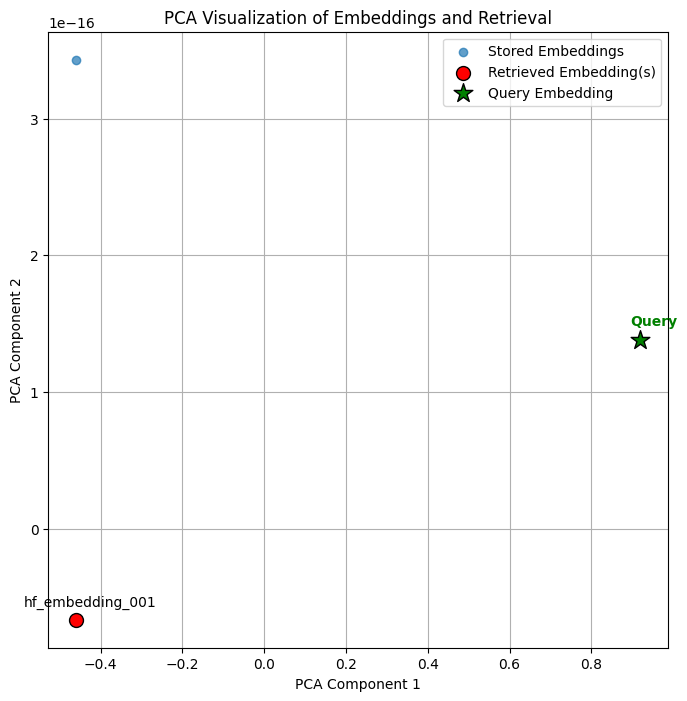

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA # Using PCA for simplicity for visualization

print("\n## Visualizing Retrieval")
print("To visualize retrieval, we can reduce the dimensionality of the embeddings (query and stored) and plot them.")
print("This helps to intuitively see which stored embeddings are closest to the query embedding.")

if 'collection' in locals() and collection is not None and query_embedding_list is not None:
    try:
        # Get all items from the collection for visualization
        all_items = collection.get(include=['embeddings', 'documents', 'metadatas'])

        if all_items and all_items.get('embeddings') and len(all_items['embeddings']) > 0:
            stored_embeddings = np.array(all_items['embeddings'])
            stored_documents = all_items['documents']
            stored_metadatas = all_items['metadatas']
            stored_ids = all_items['ids']

            # Combine stored embeddings and the query embedding for dimensionality reduction
            all_embeddings = np.vstack((stored_embeddings, np.array(query_embedding_list)))
            all_labels = stored_ids + ["Query"]

            # Use PCA for dimensionality reduction to 2 components for plotting
            # We use PCA here as it's simpler for just showing relative positions,
            # whereas t-SNE/UMAP are better for preserving local structure.
            if all_embeddings.shape[0] > 1: # Need at least 2 points for PCA
                pca = PCA(n_components=2)
                all_embeddings_pca = pca.fit_transform(all_embeddings)

                # Separate back into stored and query embeddings in 2D
                stored_embeddings_pca = all_embeddings_pca[:-1]
                query_embedding_pca = all_embeddings_pca[-1]

                # Plotting
                plt.figure(figsize=(8, 8))

                # Plot stored embeddings
                plt.scatter(stored_embeddings_pca[:, 0], stored_embeddings_pca[:, 1], label='Stored Embeddings', alpha=0.7)

                # Highlight the retrieved embedding(s) if available
                if retrieval_results and retrieval_results.get('ids') and len(retrieval_results['ids'][0]) > 0:
                    retrieved_ids = retrieval_results['ids'][0]
                    # Find the PCA coordinates for the retrieved embeddings
                    retrieved_indices = [stored_ids.index(rid) for rid in retrieved_ids if rid in stored_ids]
                    if retrieved_indices:
                         plt.scatter(stored_embeddings_pca[retrieved_indices, 0], stored_embeddings_pca[retrieved_indices, 1],
                                     color='red', s=100, label='Retrieved Embedding(s)', edgecolors='black')
                         # Add annotation for retrieved item
                         for idx in retrieved_indices:
                              plt.annotate(stored_ids[idx], (stored_embeddings_pca[idx, 0], stored_embeddings_pca[idx, 1]), textcoords="offset points", xytext=(10,10), ha='center')


                # Plot the query embedding
                plt.scatter(query_embedding_pca[0], query_embedding_pca[1], color='green', s=200, marker='*', label='Query Embedding', edgecolors='black')
                plt.annotate("Query", (query_embedding_pca[0], query_embedding_pca[1]), textcoords="offset points", xytext=(10,10), ha='center', color='green', weight='bold')


                plt.title('PCA Visualization of Embeddings and Retrieval')
                plt.xlabel('PCA Component 1')
                plt.ylabel('PCA Component 2')
                plt.legend()
                plt.grid(True)
                plt.show()
            else:
                 print("Not enough embeddings to perform PCA.")

        else:
            print("No embeddings found in the collection for visualization.")

    except Exception as e:
        print(f"Error visualizing retrieval: {e}")
else:
    if 'collection' not in locals() or collection is None:
         print("ChromaDB collection not available. Cannot visualize retrieval.")
    if query_embedding_list is None:
        print("Query embedding could not be generated. Cannot visualize retrieval.")